In [ ]:
import matplotlib.pyplot as plt #import for graphing
from astropy.io import ascii #import for reading csv
from google.colab import files #import for downloading graph
import math
import numpy as np
from scipy.optimize import curve_fit

In [ ]:
data = ascii.read('Braggs_Law.csv') #read in data

# assigns theta rows of csv to list
theta_100=data['Theta_100']
theta_110=data['Theta_110']
theta_210=data['Theta_210']

# assigns I rows of csv to list after adding multiplier
i_100=data['I_100']*data['Multiplier_100']
i_110=data['I_110']*data['Multiplier_110']
i_210=data['I_210']*data['Multiplier_210']

#error values
theta_e=0.5
i_100_error=0.01*data['Multiplier_100']
i_110_error=0.01*data['Multiplier_110']
i_210_error=0.01*data['Multiplier_210']

# convert column data to list
i_100l=i_100.tolist()
i_110l=i_110.compressed().tolist()
i_210l=i_210.compressed().tolist()

# define gaussian distribution
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

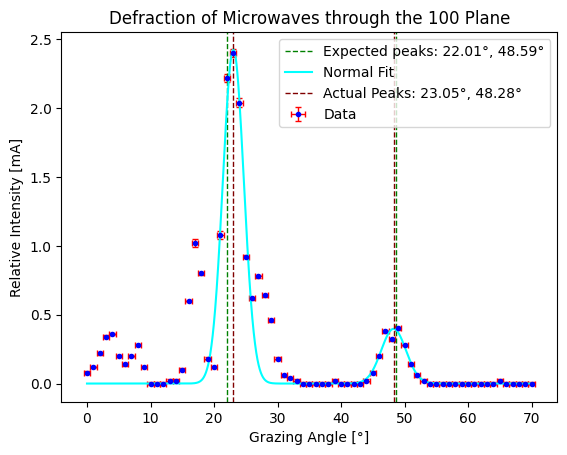

In [ ]:
#plot data points and errors
plt.errorbar(theta_100,i_100,yerr=i_100_error,xerr=theta_e,fmt='.',ecolor='red', linewidth=1, color='blue',capsize=2,label='Data')
plt.xlabel('Grazing Angle [°]')
plt.ylabel('Relative Intensity [mA]')
plt.title('Defraction of Microwaves through the 100 Plane')

# plot expected vaule
plt.axvline(x=22.01, color='green', linestyle='--', linewidth=1, label='Expected peaks: 22.01°, 48.59°')
plt.axvline(x=48.59, color='green', linestyle='--', linewidth=1)

# create gaussian fit of first peak (Parameters guesses Calculated in Desmos)
x_data=np.array(theta_100[20:30])
y_data=np.array(i_100[20:30])
popt1, pcov1 = curve_fit(gaussian, x_data, y_data,p0=[2.5, 23, 2])
A1, mu1, sigma1 = popt1
x=np.linspace(0,70,10000)
plt.plot(x[:5000],gaussian(x[:5000],A1,mu1,sigma1),color='cyan',label='Normal Fit')

# create gaussian fit of the second peak (Parameters guesses Calculated in Desmos)
x_data=np.array(theta_100[44:55])
y_data=np.array(i_100[44:55])
popt2, pcov2 = curve_fit(gaussian, x_data, y_data,p0=[0.4, 48, 2])
A2, mu2, sigma2 = popt2
plt.plot(x[5000:],gaussian(x[5000:],A2,mu2,sigma2),color='cyan')

# plot actual peak
plt.axvline(x=mu1, color='maroon', linestyle='--', linewidth=1, label=f'Actual Peaks: {mu1:.2f}°, {mu2:.2f}°')
plt.axvline(x=mu2, color='maroon', linestyle='--', linewidth=1)

plt.legend() # add legend

plt.plot()

plt.savefig('diffraction_100_plot.pdf', format='pdf', bbox_inches='tight') # create pdf of graph

err1=(sum((mu1-theta_100[i])**2 for i in range(20, 30))/9)**(1/2)

err2=(sum((mu2-theta_100[i])**2 for i in range(44, 55))/10)**(1/2)

#files.download('diffraction_100_plot.pdf') # download pdf

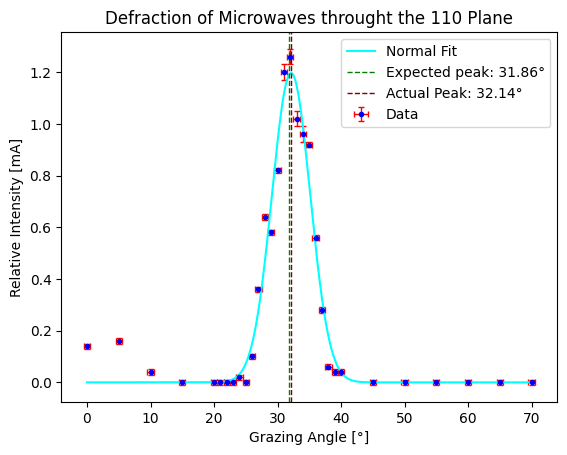

In [ ]:
#plot data points and errors
plt.errorbar(theta_110,i_110,yerr=i_110_error,xerr=theta_e,fmt='.',ecolor='red', linewidth=1, color='blue',capsize=2,label='Data')
plt.xlabel('Grazing Angle [°]')
plt.ylabel('Relative Intensity [mA]')
plt.title('Defraction of Microwaves throught the 110 Plane')

# create gaussian fit (Parameters guesses Calculated in Desmos)
x_data=np.array(theta_110[3:26])
y_data=np.array(i_110[3:26])
popt3, pcov3 = curve_fit(gaussian, x_data, y_data,p0=[1.2, 32, 3])
A3, mu3, sigma3 = popt3
plt.plot(x,gaussian(x,A3,mu3,sigma3),color='cyan', label='Normal Fit')

plt.axvline(x=31.86, color='green', linestyle='--', linewidth=1, label='Expected peak: 31.86°') # plot expected value

plt.axvline(x=mu3, color='maroon', linestyle='--', linewidth=1, label=f'Actual Peak: {mu3:.2f}°') # plot actual peak

plt.legend(loc='upper right') #add legend

plt.plot()

plt.savefig('diffraction_plot_110.pdf', format='pdf', bbox_inches='tight') # create pdf of graph

err3=(sum((mu3-theta_110[i])**2 for i in range(3, 26))/22)**(1/2)

#files.download('diffraction_plot_110.pdf') # download pdf

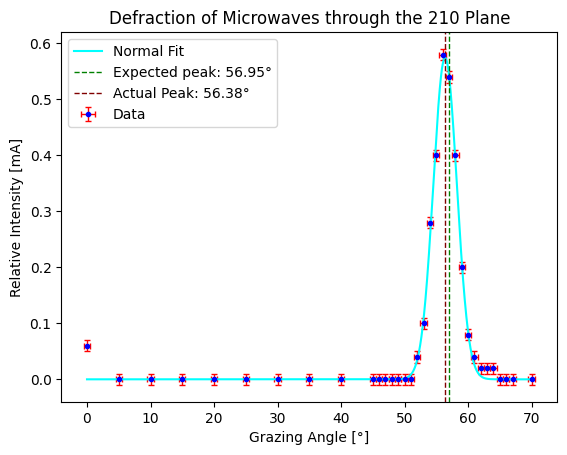

In [ ]:
#plot data points and error
plt.errorbar(theta_210,i_210,yerr=i_210_error,xerr=theta_e,fmt='.',ecolor='red', linewidth=1, color='blue',capsize=2,label='Data')
plt.xlabel('Grazing Angle [°]')
plt.ylabel('Relative Intensity [mA]')
plt.title('Defraction of Microwaves through the 210 Plane')

# create gaussian fit (Parameters guesses Calculated in Desmos)
x_data=np.array(theta_210[11:31])
y_data=np.array(i_210[11:31])
popt4, pcov4 = curve_fit(gaussian, x_data, y_data,p0=[0.6, 56, 1.9])
A4, mu4, sigma4 = popt4
plt.plot(x,gaussian(x,A4,mu4,sigma4),color='cyan',label='Normal Fit')

plt.axvline(x=56.95, color='green', linestyle='--', linewidth=1, label='Expected peak: 56.95°') # plot expected value

plt.axvline(x=mu4, color='maroon', linestyle='--', linewidth=1, label=f'Actual Peak: {mu4:.2f}°') # plot actual peak

plt.legend(loc='upper left') # add legend

plt.plot()

plt.savefig('diffraction_plot_210.pdf', format='pdf', bbox_inches='tight') # create pdf of graph

err4=(sum((mu4-theta_210[i])**2 for i in range(11, 31))/19)**(1/2)

#files.download('diffraction_plot_210.pdf') #download pdf

In [ ]:
#convert to LaTex
pairs = list(zip(theta_100, i_100,i_100_error))
for i in range(0, len(pairs), 2):
    chunk = pairs[i:i+2]
    line = " & ".join(f"{t} & {val:.2f} & {err:.2f}" for t, val,err in chunk)
    print(line + r" \\")
    print('\\hline')

0 & 0.08 & 0.01 & 1 & 0.12 & 0.01 \\
\hline
2 & 0.22 & 0.01 & 3 & 0.34 & 0.01 \\
\hline
4 & 0.36 & 0.01 & 5 & 0.20 & 0.01 \\
\hline
6 & 0.14 & 0.01 & 7 & 0.20 & 0.01 \\
\hline
8 & 0.28 & 0.01 & 9 & 0.12 & 0.01 \\
\hline
10 & 0.00 & 0.01 & 11 & 0.00 & 0.01 \\
\hline
12 & 0.00 & 0.01 & 13 & 0.02 & 0.01 \\
\hline
14 & 0.02 & 0.01 & 15 & 0.10 & 0.01 \\
\hline
16 & 0.60 & 0.01 & 17 & 1.02 & 0.03 \\
\hline
18 & 0.80 & 0.01 & 19 & 0.18 & 0.01 \\
\hline
20 & 0.12 & 0.01 & 21 & 1.08 & 0.03 \\
\hline
22 & 2.22 & 0.03 & 23 & 2.40 & 0.03 \\
\hline
24 & 2.04 & 0.03 & 25 & 0.92 & 0.01 \\
\hline
26 & 0.62 & 0.01 & 27 & 0.78 & 0.01 \\
\hline
28 & 0.64 & 0.01 & 29 & 0.46 & 0.01 \\
\hline
30 & 0.18 & 0.01 & 31 & 0.06 & 0.01 \\
\hline
32 & 0.04 & 0.01 & 33 & 0.02 & 0.01 \\
\hline
34 & 0.00 & 0.01 & 35 & 0.00 & 0.01 \\
\hline
36 & 0.00 & 0.01 & 37 & 0.00 & 0.01 \\
\hline
38 & 0.00 & 0.01 & 39 & 0.02 & 0.01 \\
\hline
40 & 0.00 & 0.01 & 41 & 0.00 & 0.01 \\
\hline
42 & 0.00 & 0.01 & 43 & 0.00 & 0.01 \\
\hlin

In [ ]:
#convert to LaTex
pairs = list(zip(theta_110.compressed(), i_110.compressed(),i_110_error.compressed()))
for i in range(0, len(pairs), 2):
    chunk = pairs[i:i+2]
    line = " & ".join(f"{t} & {val:.2f} & {err:.2f}" for t, val,err in chunk)
    print(line + r" \\")
    print('\\hline')

0 & 0.14 & 0.01 & 5 & 0.16 & 0.01 \\
\hline
10 & 0.04 & 0.01 & 15 & 0.00 & 0.01 \\
\hline
20 & 0.00 & 0.01 & 21 & 0.00 & 0.01 \\
\hline
22 & 0.00 & 0.01 & 23 & 0.00 & 0.01 \\
\hline
24 & 0.02 & 0.01 & 25 & 0.00 & 0.01 \\
\hline
26 & 0.10 & 0.01 & 27 & 0.36 & 0.01 \\
\hline
28 & 0.64 & 0.01 & 29 & 0.58 & 0.01 \\
\hline
30 & 0.82 & 0.01 & 31 & 1.20 & 0.03 \\
\hline
32 & 1.26 & 0.03 & 33 & 1.02 & 0.03 \\
\hline
34 & 0.96 & 0.03 & 35 & 0.92 & 0.01 \\
\hline
36 & 0.56 & 0.01 & 37 & 0.28 & 0.01 \\
\hline
38 & 0.06 & 0.01 & 39 & 0.04 & 0.01 \\
\hline
40 & 0.04 & 0.01 & 45 & 0.00 & 0.01 \\
\hline
50 & 0.00 & 0.01 & 55 & 0.00 & 0.01 \\
\hline
60 & 0.00 & 0.01 & 65 & 0.00 & 0.01 \\
\hline
70 & 0.00 & 0.01 \\
\hline


In [ ]:
#convert to LaTex
pairs = list(zip(theta_210.compressed(), i_210.compressed(),i_210_error.compressed()))
for i in range(0, len(pairs), 2):
    chunk = pairs[i:i+2]
    line = " & ".join(f"{t} & {val:.2f} & {err:.2f}" for t, val,err in chunk)
    print(line + r" \\")
    print('\\hline')

0 & 0.06 & 0.01 & 5 & 0.00 & 0.01 \\
\hline
10 & 0.00 & 0.01 & 15 & 0.00 & 0.01 \\
\hline
20 & 0.00 & 0.01 & 25 & 0.00 & 0.01 \\
\hline
30 & 0.00 & 0.01 & 35 & 0.00 & 0.01 \\
\hline
40 & 0.00 & 0.01 & 45 & 0.00 & 0.01 \\
\hline
46 & 0.00 & 0.01 & 47 & 0.00 & 0.01 \\
\hline
48 & 0.00 & 0.01 & 49 & 0.00 & 0.01 \\
\hline
50 & 0.00 & 0.01 & 51 & 0.00 & 0.01 \\
\hline
52 & 0.04 & 0.01 & 53 & 0.10 & 0.01 \\
\hline
54 & 0.28 & 0.01 & 55 & 0.40 & 0.01 \\
\hline
56 & 0.58 & 0.01 & 57 & 0.54 & 0.01 \\
\hline
58 & 0.40 & 0.01 & 59 & 0.20 & 0.01 \\
\hline
60 & 0.08 & 0.01 & 61 & 0.04 & 0.01 \\
\hline
62 & 0.02 & 0.01 & 63 & 0.02 & 0.01 \\
\hline
64 & 0.02 & 0.01 & 65 & 0.00 & 0.01 \\
\hline
66 & 0.00 & 0.01 & 67 & 0.00 & 0.01 \\
\hline
70 & 0.00 & 0.01 \\
\hline


In [ ]:
# calculate a value for n=1 in 100 plane
d1_100=(1*2.85)/(2*math.sin(math.radians(mu1)))
err_d1_100=(1*2.58*math.cos(math.radians(mu1)))/(2*math.sin(math.radians(mu1))**2)*math.radians(err1)
a1_100=d1_100
err_a1_100=err_d1_100
print(f"n=1, a_100={a1_100:.1f}±{err_a1_100:.1f} cm")

# calculate a value for n=2 in 100 plane
d2_100=(2*2.85)/(2*math.sin(math.radians(mu2)))
err_d2_100=(2*2.58*math.cos(math.radians(mu2)))/(2*math.sin(math.radians(mu2))**2)*math.radians(err2)
a2_100=d2_100
err_a2_100=err_d2_100
print(f"n=2, a_100={a2_100:.2f}±{err_a2_100:.2f} cm")

# calculate a for 110 plane
d_110=(1*2.85)/(2*math.sin(math.radians(mu3)))
err_d_110=(1*2.58*math.cos(math.radians(mu3)))/(2*math.sin(math.radians(mu3))**2)*math.radians(err3)
a_110=d_110*(2**(1/2))
err_a_110=err_d_110*(2**(1/2))
print(f"n=1, a_110={a_110:.2f}±{err_a_110:.1f} cm")

# calculate a for 210 plane
d_210=(1*2.85)/(2*math.sin(math.radians(mu4)))
err_d_210=(1*2.58*math.cos(math.radians(mu4)))/(2*math.sin(math.radians(mu4))**2)*math.radians(err4)
a_210=d_210*(5**(1/2))
err_a_210=err_d_210*(5**(1/2))
print(f"n=1, a_210={a_210:.1f}±{err_a_210:.1f} cm")

# calulate weighted average of a
w_a1_100=1/(err_a1_100**2)
w_a2_100=1/(err_a2_100**2)
w_a_110=1/(err_a_110**2)
w_a_210=1/(err_a_210**2)
a_avg=(a1_100*w_a1_100+a2_100*w_a2_100+a_110*w_a_110+a_210*w_a_210)/(w_a1_100+w_a2_100+w_a_110+w_a_210)
err_a_avg=1/(w_a1_100+w_a2_100+w_a_110+w_a_210)**(1/2)
print(f"a_avg={a_avg:.2f}±{err_a_avg:.2f} cm")

n=1, a_100=3.6±0.5 cm
n=2, a_100=3.82±0.18 cm
n=1, a_110=3.79±0.7 cm
n=1, a_210=3.8±0.2 cm
a_avg=3.80±0.14 cm


In [ ]:
# calculate agreement
a_meas=(15.02+14.80+14.85+14.97)/(16)
agree_a1_100=abs(a_meas-a1_100)/(err_a1_100**2+(0.005/16)**2)**(1/2)
agree_a2_100=abs(a_meas-a2_100)/(err_a2_100**2+(0.005/16)**2)**(1/2)
agree_a_110=abs(a_meas-a_110)/(err_a_110**2+(0.005/16)**2)**(1/2)
agree_a_210=abs(a_meas-a_210)/(err_a_210**2+(0.005/16)**2)**(1/2)
agree_a_avg=abs(a_meas-a_avg)/(err_a_avg**2+(0.005/16)**2)**(1/2)
print(f"agreement for n=1 a_100 is {agree_a1_100:.2f}")
print(f"agreement for n=2 a_100 is {agree_a2_100:.2f}")
print(f"agreement for n=1 a_110 is {agree_a_110:.2f}")
print(f"agreement for n=1 a_210 is {agree_a_210:.2f}")
print(f"agreement for a_avg is {agree_a_avg:.2f}")

agreement for n=1 a_100 is 0.19
agreement for n=2 a_100 is 0.50
agreement for n=1 a_110 is 0.08
agreement for n=1 a_210 is 0.42
agreement for a_avg is 0.57
